In [1]:
import numpy as np
#import matplotlib.pyplot as plt

In [2]:
def prob(x1,x2):
    return np.exp(-(x1*x2))

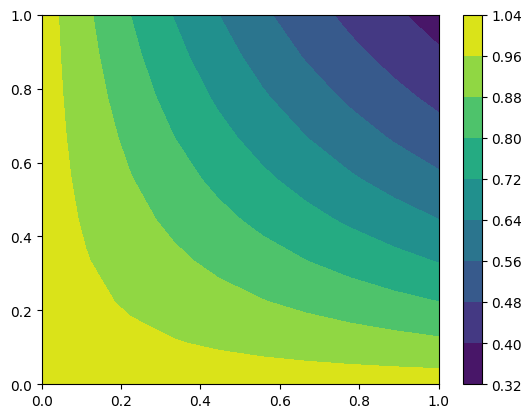

In [3]:
x1 = np.linspace(0,1,10)
x2 = np.linspace(0,1,10)
X1,X2 = np.meshgrid(x1,x2)
P = prob(X1,X2)

plt.contourf(X1,X2,P)
plt.colorbar()
plt.show()

In [12]:
"""
Bernoulli Level Set Estimation with AEPsych
============================================
Finds the 0.5-probability threshold contour of a black-box binary function
using the GlobalMI look-ahead acquisition function from the bernoulli_lse paper.

The bernoulli_lse repo is a research benchmark harness; the actual algorithm
lives in AEPsych (pip install aepsych). This script shows how to wire it up
for your own function with a small budget.

Install:
    pip install aepsych matplotlib
"""

import logging
import numpy as np
import torch
import matplotlib.pyplot as plt
from aepsych.config import Config
from aepsych.strategy import SequentialStrategy

# ── Silence AEPsych's per-trial INFO logs (set to WARNING to quieten, DEBUG to see all)
logging.getLogger("aepsych").setLevel(logging.WARNING)


# ---------------------------------------------------------------------------
# 1.  YOUR BLACK-BOX FUNCTION
#     Replace this with a call to your actual circuit simulator.
#     It receives two parameter values and must return 0 or 1 (success/failure).
# ---------------------------------------------------------------------------

def true_prob(x1: float, x2: float) -> float:
    """Ground-truth success probability (unknown in practice)."""
    return np.exp(-(x1 * x2))


def run_circuit(x1: float, x2: float) -> int:
    """
    Simulate one circuit trial.  In your real setup this calls your blackbox
    and observes a binary success (1) or failure (0).
    """
    p = true_prob(x1, x2)
    return int(np.random.rand() < p)


# ---------------------------------------------------------------------------
# 2.  STRATEGY CONFIGURATION
#
#     Two stages:
#       init_strat  – quasi-random Sobol points to warm-start the GP
#       opt_strat   – GlobalMI acquisition: the look-ahead LSE acquisition
#                     from Letham et al. 2022 (the bernoulli_lse paper)
#
#     Acquisition function options (drop-in replacements for GlobalMI):
#       GlobalMI        – Global Mutual Information  (paper's best pick)
#       LocalMI         – Local variant (cheaper)
#       GlobalSUR       – Global SUR
#       LocalSUR        – Local SUR (cheaper)
#       EAVC            – Expected Active Volume Change
#       ApproxGlobalSUR – Fast approximation of GlobalSUR
#       MCLevelSetEstimation – "Straddle" heuristic (classic baseline)
# ---------------------------------------------------------------------------

INIT_TRIALS  = 10    # Sobol warm-up trials (rule of thumb: ~4×n_dims)
OPT_TRIALS   = 590   # Adaptive trials using the LSE acquisition
TARGET       = 0.5  # Probability threshold we want to find

# Parameter bounds: [lower, upper] for each dimension
X1_LB, X1_UB = 0.1, 3.0
X2_LB, X2_UB = 0.1, 3.0

config_str = f"""
[common]
parnames = [x1, x2]
outcome_types = [binary]
strategy_names = [init_strat, opt_strat]

[x1]
par_type = continuous
lower_bound = {X1_LB}
upper_bound = {X1_UB}

[x2]
par_type = continuous
lower_bound = {X2_LB}
upper_bound = {X2_UB}

[init_strat]
min_asks = {INIT_TRIALS}
generator = SobolGenerator

[opt_strat]
min_asks = {OPT_TRIALS}
model = GPClassificationModel
generator = OptimizeAcqfGenerator

[GPClassificationModel]
# inducing_size: number of sparse GP inducing points.
# 20-50 is fine for 2-D; increase for higher-dimensional problems.
inducing_size = 50

[OptimizeAcqfGenerator]
acqf = GlobalSUR
restarts = 8   # multistart restarts for acqf optimisation
samps = 20000    # MC samples for the look-ahead integral

[GlobalSUR]
target = {TARGET}
"""


# ---------------------------------------------------------------------------
# 3.  RUN THE ACTIVE LEARNING LOOP
# ---------------------------------------------------------------------------

def run_lse():
    config = Config()
    config.update(config_str=config_str)
    strat = SequentialStrategy.from_config(config)

    np.random.seed(0)
    results = []

    trial = 0
    while not strat.finished:
        # Ask the strategy for the next point to evaluate
        x = strat.gen()               # shape: (1, n_params)
        x1_val = x[0, 0].item()
        x2_val = x[0, 1].item()

        # --- call your black-box here ---
        outcome = run_circuit(x1_val, x2_val)

        # Tell the strategy about the result
        strat.add_data(x, [outcome])

        phase = "init" if trial < INIT_TRIALS else "opt"
        results.append({
            "trial": trial,
            "phase": phase,
            "x1": x1_val,
            "x2": x2_val,
            "outcome": outcome,
            "true_prob": true_prob(x1_val, x2_val),
        })
        print(
            f"[{phase:4s}] trial {trial:3d}  x1={x1_val:.3f}  x2={x2_val:.3f}"
            f"  p_true={true_prob(x1_val, x2_val):.3f}  outcome={outcome}"
        )
        trial += 1

    print(f"\nDone — {trial} total trials.")
    return strat, results


# ---------------------------------------------------------------------------
# 4.  EXTRACT THE ESTIMATED THRESHOLD CONTOUR
# ---------------------------------------------------------------------------

def plot_results(strat, results):
    # Build a fine grid and query the fitted GP for posterior mean
    n = 100
    x1g = np.linspace(X1_LB, X1_UB, n)
    x2g = np.linspace(X2_LB, X2_UB, n)
    X1, X2 = np.meshgrid(x1g, x2g)
    grid = torch.tensor(
        np.stack([X1.ravel(), X2.ravel()], axis=1), dtype=torch.double
    )

    # strat.model is the final fitted GP; predict returns (mean_f, var_f)
    # We want p = Φ(mean_f) (probit link)
    with torch.no_grad():
        model = strat.model
        f_mean, _ = model.predict(grid)
        from scipy.special import ndtr
        p_pred = ndtr(f_mean.numpy())   # Φ(f) = probit CDF

    P = p_pred.reshape(n, n)

    # Ground truth
    P_true = true_prob(X1, X2)

    # Sampled points
    xs = [r for r in results]
    init_pts = [r for r in xs if r["phase"] == "init"]
    opt_pts  = [r for r in xs if r["phase"] == "opt"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, P_plot, title in zip(
        axes,
        [P_true, P],
        ["True probability  p(x1,x2) = exp(−x1·x2)", "GP posterior mean probability"],
    ):
        cm = ax.contourf(X1, X2, P_plot, levels=20, cmap="RdYlGn")
        ax.contour(X1, X2, P_plot, levels=[TARGET], colors="k", linewidths=2)
        plt.colorbar(cm, ax=ax)
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
        ax.set_title(title)

    # Overlay sampled points on posterior plot
    ax = axes[1]
    ax.scatter(
        [r["x1"] for r in init_pts], [r["x2"] for r in init_pts],
        c="blue", marker="o", s=40, label="Sobol init", zorder=5, alpha=0.7,
    )
    ax.scatter(
        [r["x1"] for r in opt_pts], [r["x2"] for r in opt_pts],
        c="white", edgecolors="black", marker="^", s=50, label="GlobalMI", zorder=6, alpha=0.9,
    )
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(
        f"GP posterior mean  (black line = estimated p={TARGET} contour)\n"
        f"{INIT_TRIALS} Sobol + {OPT_TRIALS} GlobalMI = {INIT_TRIALS+OPT_TRIALS} total trials"
    )

    plt.tight_layout()
    plt.savefig("lse_result.png", dpi=150)
    print("Plot saved to lse_result.png")
    plt.show()


# ---------------------------------------------------------------------------
# 5.  MAIN
# ---------------------------------------------------------------------------


strat, results = run_lse()
plot_results(strat, results)


2026-06-03 13:25:04,584 [INFO   ] Starting fitting (no warm start)...


[init] trial   0  x1=2.241  x2=2.234  p_true=0.007  outcome=0
[init] trial   1  x1=0.179  x2=0.619  p_true=0.895  outcome=1
[init] trial   2  x1=1.362  x2=2.843  p_true=0.021  outcome=0
[init] trial   3  x1=2.517  x2=1.229  p_true=0.045  outcome=0
[init] trial   4  x1=2.797  x2=2.513  p_true=0.001  outcome=0
[init] trial   5  x1=1.052  x2=0.887  p_true=0.393  outcome=0
[init] trial   6  x1=0.799  x2=1.851  p_true=0.228  outcome=0
[init] trial   7  x1=1.637  x2=0.225  p_true=0.692  outcome=0
[init] trial   8  x1=1.845  x2=2.774  p_true=0.006  outcome=0
[init] trial   9  x1=0.508  x2=1.522  p_true=0.462  outcome=1


2026-06-03 13:25:04,881 [INFO   ] Fitting done, took 0.29764628410339355
2026-06-03 13:25:04,885 [INFO   ] Starting gen...
2026-06-03 13:25:09,957 [INFO   ] Gen done, time=5.070154428482056
2026-06-03 13:25:09,957 [INFO   ] Starting fitting (no warm start)...
2026-06-03 13:25:10,161 [INFO   ] Fitting done, took 0.20375967025756836


[opt ] trial  10  x1=0.256  x2=1.166  p_true=0.742  outcome=0


2026-06-03 13:25:10,161 [INFO   ] Starting gen...
2026-06-03 13:25:15,388 [INFO   ] Gen done, time=5.227619647979736
2026-06-03 13:25:15,390 [INFO   ] Starting fitting (no warm start)...


...

[opt ] trial 371  x1=0.515  x2=1.224  p_true=0.533  outcome=1


2026-06-03 14:37:05,761 [INFO   ] Fitting done, took 3.423734426498413
2026-06-03 14:37:05,771 [INFO   ] Starting gen...
2026-06-03 14:37:16,726 [INFO   ] Gen done, time=10.954142808914185
2026-06-03 14:37:16,730 [INFO   ] Starting fitting (no warm start)...


[opt ] trial 372  x1=2.289  x2=0.339  p_true=0.460  outcome=0


2026-06-03 14:37:19,132 [INFO   ] Fitting done, took 2.4019734859466553
2026-06-03 14:37:19,132 [INFO   ] Starting gen...


KeyboardInterrupt: 

In [4]:
import matplotlib.pyplot as plt

C:\Users\Rick\AppData\Local\Temp\ipykernel_21052\2830669344.py:52: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


Plot saved to lse_result.png


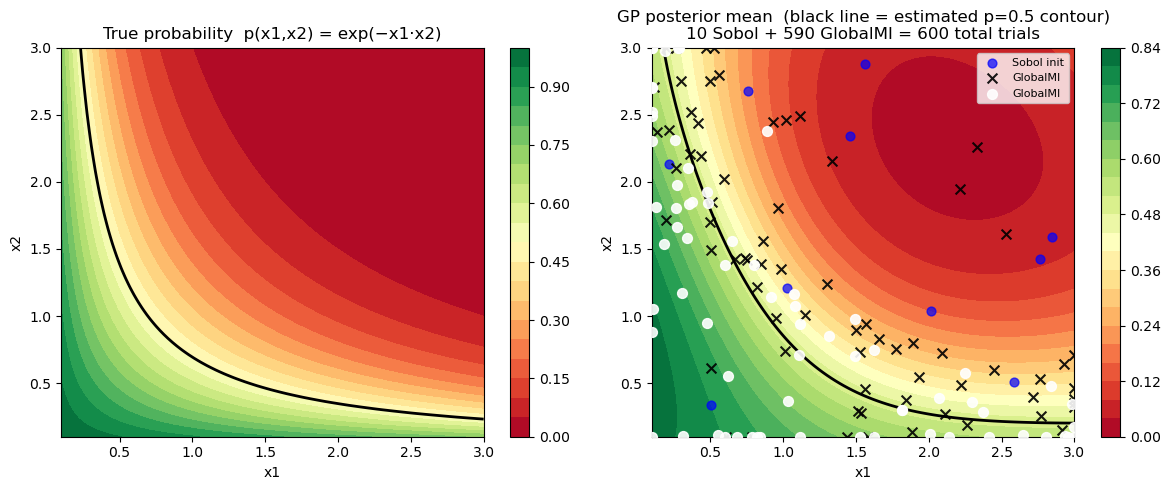

In [13]:
# Build a fine grid and query the fitted GP for posterior mean
n = 100
x1g = np.linspace(X1_LB, X1_UB, n)
x2g = np.linspace(X2_LB, X2_UB, n)
X1, X2 = np.meshgrid(x1g, x2g)
grid = torch.tensor(
    np.stack([X1.ravel(), X2.ravel()], axis=1), dtype=torch.double
)

# strat.model is the final fitted GP; predict returns (mean_f, var_f)
# We want p = Φ(mean_f) (probit link)
with torch.no_grad():
    model = strat.model
    f_mean, _ = model.predict(grid)
    from scipy.special import ndtr
    p_pred = ndtr(f_mean.numpy())   # Φ(f) = probit CDF

P = p_pred.reshape(n, n)

# Ground truth
P_true = true_prob(X1, X2)

# Sampled points
xs = [r for r in results]
init_pts = [r for r in xs if r["phase"] == "init"]
opt_pts  = [r for r in xs if r["phase"] == "opt"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, P_plot, title in zip(
    axes,
    [P_true, P],
    ["True probability  p(x1,x2) = exp(−x1·x2)", "GP posterior mean probability"],
):
    cm = ax.contourf(X1, X2, P_plot, levels=20, cmap="RdYlGn")
    ax.contour(X1, X2, P_plot, levels=[TARGET], colors="k", linewidths=2)
    plt.colorbar(cm, ax=ax)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title)

# Overlay sampled points on posterior plot
ax = axes[1]
ax.scatter(
    [r["x1"] for r in init_pts], [r["x2"] for r in init_pts],
    c="blue", marker="o", s=40, label="Sobol init", zorder=5, alpha=0.7,
)
# ax.scatter(
#     [r["x1"] for r in opt_pts], [r["x2"] for r in opt_pts],
#     c="white", edgecolors="black", marker="^", s=50, label="GlobalMI", zorder=6, alpha=0.9,
# )

ax.scatter(
    [r["x1"] for r in opt_pts if r['outcome'] == 0], [r["x2"] for r in opt_pts if r['outcome'] == 0],
    c="black", edgecolors="black", marker="x", s=50, label="GlobalMI", zorder=6, alpha=0.9,
)
ax.scatter(
    [r["x1"] for r in opt_pts if r['outcome'] == 1], [r["x2"] for r in opt_pts if r['outcome'] == 1],
    c="white", edgecolors="white", marker="o", s=50, label="GlobalMI", zorder=6, alpha=0.9,
)

ax.legend(loc="upper right", fontsize=8)
ax.set_title(
    f"GP posterior mean  (black line = estimated p={TARGET} contour)\n"
    f"{INIT_TRIALS} Sobol + {OPT_TRIALS} GlobalMI = {INIT_TRIALS+OPT_TRIALS} total trials"
)

plt.tight_layout()
plt.savefig("lse_result.png", dpi=150)
print("Plot saved to lse_result.png")
plt.show()